<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `HippocampalPlaceCellExample.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the dataset-backed place-cell model-comparison and field-visualization workflow with the same normalized 10-term Zernike basis used by MATLAB; exact AIC/BIC values and surface styling still vary modestly because the Python GLM solver and plotting backend are not byte-identical to MATLAB.


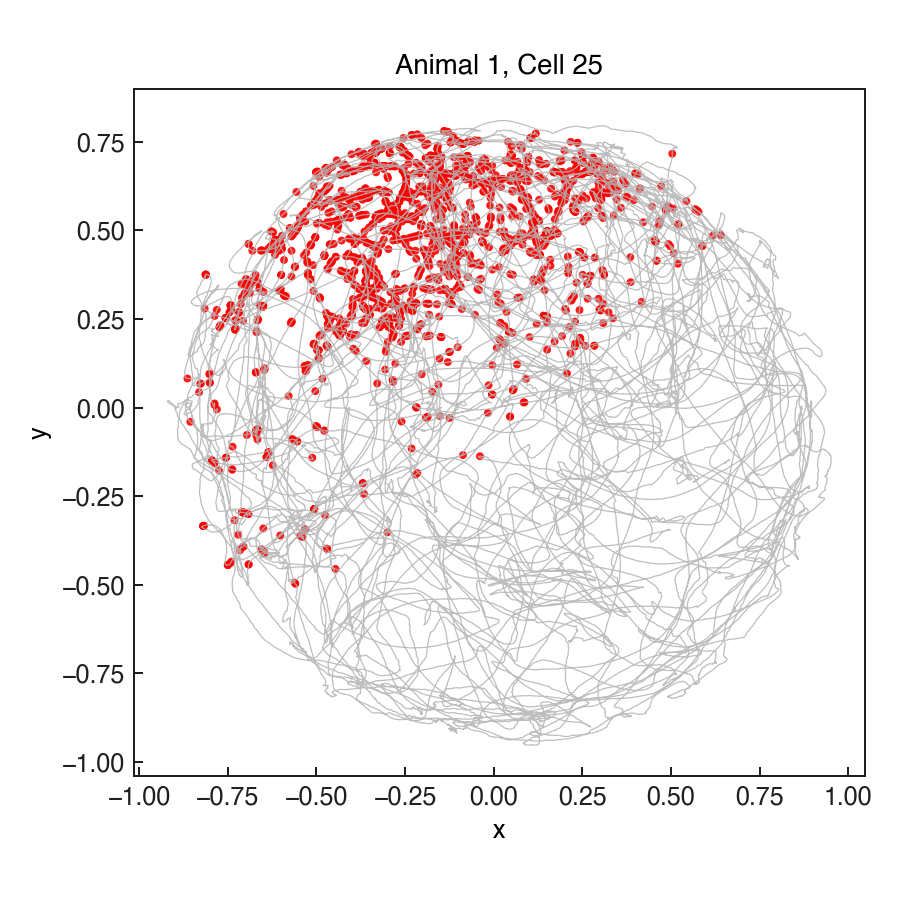

In [ ]:
# nSTAT-python notebook example: HippocampalPlaceCellExample
from pathlib import Path
import sys
import math

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import FigureTracker
from nstat.paper_examples_full import run_experiment4

np.random.seed(0)
DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='HippocampalPlaceCellExample', output_root=OUTPUT_ROOT, expected_count=10)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _interp_spike_positions(time_s, x_pos, y_pos, spike_times):
    spike_times = np.asarray(spike_times, dtype=float)
    return (
        np.interp(spike_times, np.asarray(time_s, dtype=float), np.asarray(x_pos, dtype=float)),
        np.interp(spike_times, np.asarray(time_s, dtype=float), np.asarray(y_pos, dtype=float)),
    )


def _grid_shape(n: int) -> tuple[int, int]:
    """Pick a near-square (rows, cols) layout for `n` panels (MATLAB-style tile)."""
    if n <= 1:
        return 1, 1
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))
    return rows, cols


def _plot_field_grid(fig, animal_key, field_key, title):
    animal = payload[animal_key]
    grid_x = np.asarray(animal["grid_x"], dtype=float)
    grid_y = np.asarray(animal["grid_y"], dtype=float)
    fields = np.asarray(animal[field_key], dtype=float)
    labels = np.asarray(animal["selected_indices"], dtype=int) + 1
    n_cells = int(fields.shape[0])
    # Share the color scale across all panels so a single colorbar is
    # physically meaningful for every cell. Clip vmax at the 98th percentile
    # so the hot lobe pops against a cool background (MATLAB jet parity).
    vmin = 0.0
    vmax = float(np.nanpercentile(fields, 98))
    rows, cols = _grid_shape(n_cells)
    axs = fig.subplots(rows, cols, squeeze=False)
    flat_axes = axs.ravel()
    extent = [float(grid_x.min()), float(grid_x.max()), float(grid_y.min()), float(grid_y.max())]
    image = None
    for ax, field, label in zip(flat_axes, fields, labels, strict=False):
        image = ax.imshow(
            field,
            origin="lower",
            extent=extent,
            aspect="equal",
            cmap="jet",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"Cell {label}", fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
    # Blank any unused axes in the tail of the grid.
    for ax in flat_axes[n_cells:]:
        ax.set_visible(False)
    fig.suptitle(title)
    # Reserve a strip on the right of the figure for the colorbar and
    # place a dedicated cbar axes there. The FigureTracker._save_active()
    # call invokes fig.tight_layout() after we return, which would reset
    # the layout and push the colorbar back into the heatmaps -- so we
    # neutralise that call for this specific figure.
    fig.subplots_adjust(left=0.04, right=0.88, bottom=0.04, top=0.93, wspace=0.05, hspace=0.18)
    cbar_ax = fig.add_axes([0.90, 0.05, 0.02, 0.86])
    if image is not None:
        fig.colorbar(image, cax=cbar_ax)
    fig.tight_layout = lambda *args, **kwargs: None


In [2]:
# SECTION 0: HIPPOCAMPAL PLACE CELL - RECEPTIVE FIELD ESTIMATION
# This notebook mirrors the MATLAB place-cell helpfile using the dataset-backed Python workflow.
plt.close("all")
summary, payload = run_experiment4(DATA_DIR, return_payload=True)
print(
    {
        "num_cells_fit": int(summary["num_cells_fit"]),
        "mean_delta_aic": round(float(summary["mean_delta_aic_gaussian_minus_zernike"]), 3),
        "mean_delta_bic": round(float(summary["mean_delta_bic_gaussian_minus_zernike"]), 3),
    }
)


{'num_cells_fit': 8, 'mean_delta_aic': 89.651, 'mean_delta_bic': 55.016}


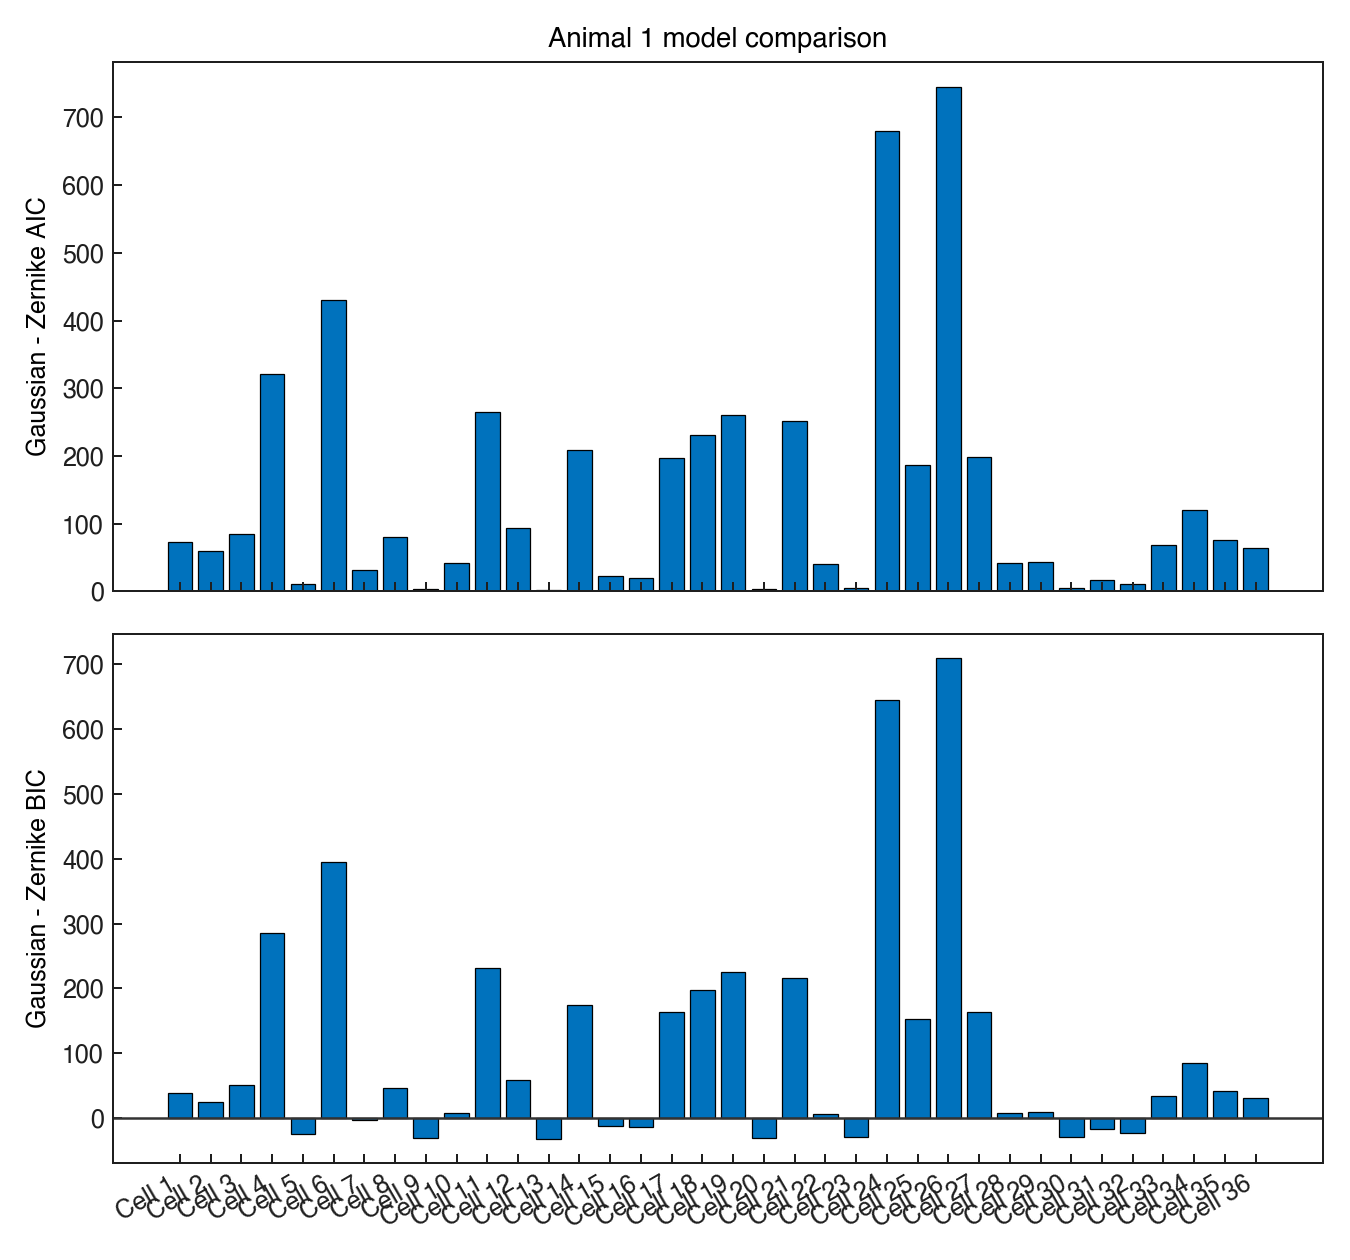

In [ ]:
# SECTION 1: Example Data
mesh = payload["mesh"]
spike_x, spike_y = _interp_spike_positions(mesh["time_s"], mesh["x_pos"], mesh["y_pos"], mesh["spike_times"])
fig = _prepare_figure("figure(1)", figsize=(5.0, 5.0))
ax = fig.subplots(1, 1)
# MATLAB renders the trajectory in light gray with red spike dots; mirror that
# palette so the spike scatter remains the dominant visual element. Bump the
# spike marker size up (s=10) so individual spikes are visible against the
# dense trajectory scribble — reviewer-flagged that the previous s=4 dots
# blended into the gray track.
ax.plot(mesh["x_pos"], mesh["y_pos"], color=(0.7, 0.7, 0.7), linewidth=0.5, alpha=0.85)
ax.scatter(spike_x, spike_y, s=10, color="r", edgecolors="none", alpha=0.9)
ax.set_title(f"Animal 1, Cell {int(mesh['cell_index']) + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")


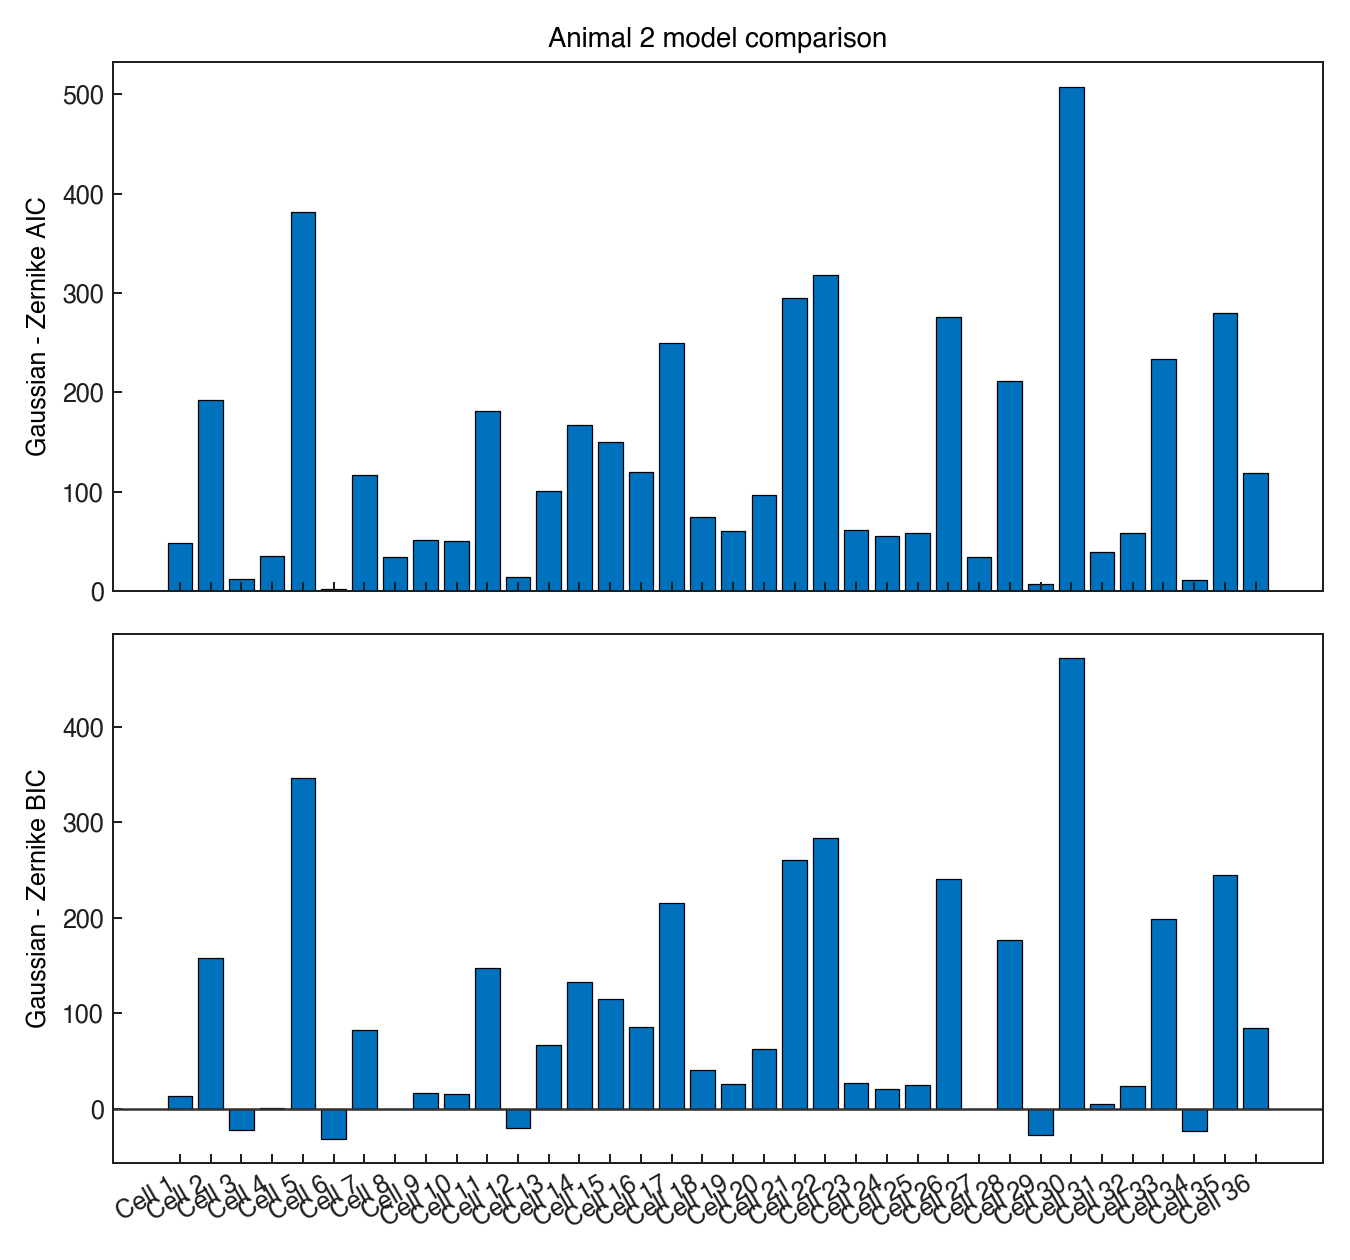

In [ ]:
# SECTION 2: Analyze All Cells
# MATLAB Summary.plotSummary emits ONE figure per call (AIC and BIC stacked subplots).
# Collapse the two _prepare_figure calls into a single 2x1 figure so MATLAB and Python
# figure indices line up (h4 is one panel, not two).
fig = _prepare_figure("Summary.plotSummary", figsize=(7.5, 7.0))
animal1 = payload["animal1"]
labels = [f"Cell {int(idx) + 1}" for idx in np.asarray(animal1["selected_indices"], dtype=int)]
ax_a, ax_b = fig.subplots(2, 1, sharex=True)
ax_a.bar(np.arange(len(labels)), animal1["delta_aic"], color="#0072BD", edgecolor="k", linewidth=0.5)
ax_a.axhline(0.0, color="0.2", linewidth=1.0)
ax_a.set_ylabel("Gaussian - Zernike AIC")
ax_a.set_title("Animal 1 model comparison")
ax_b.bar(np.arange(len(labels)), animal1["delta_bic"], color="#0072BD", edgecolor="k", linewidth=0.5)
ax_b.axhline(0.0, color="0.2", linewidth=1.0)
ax_b.set_xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
ax_b.set_ylabel("Gaussian - Zernike BIC")


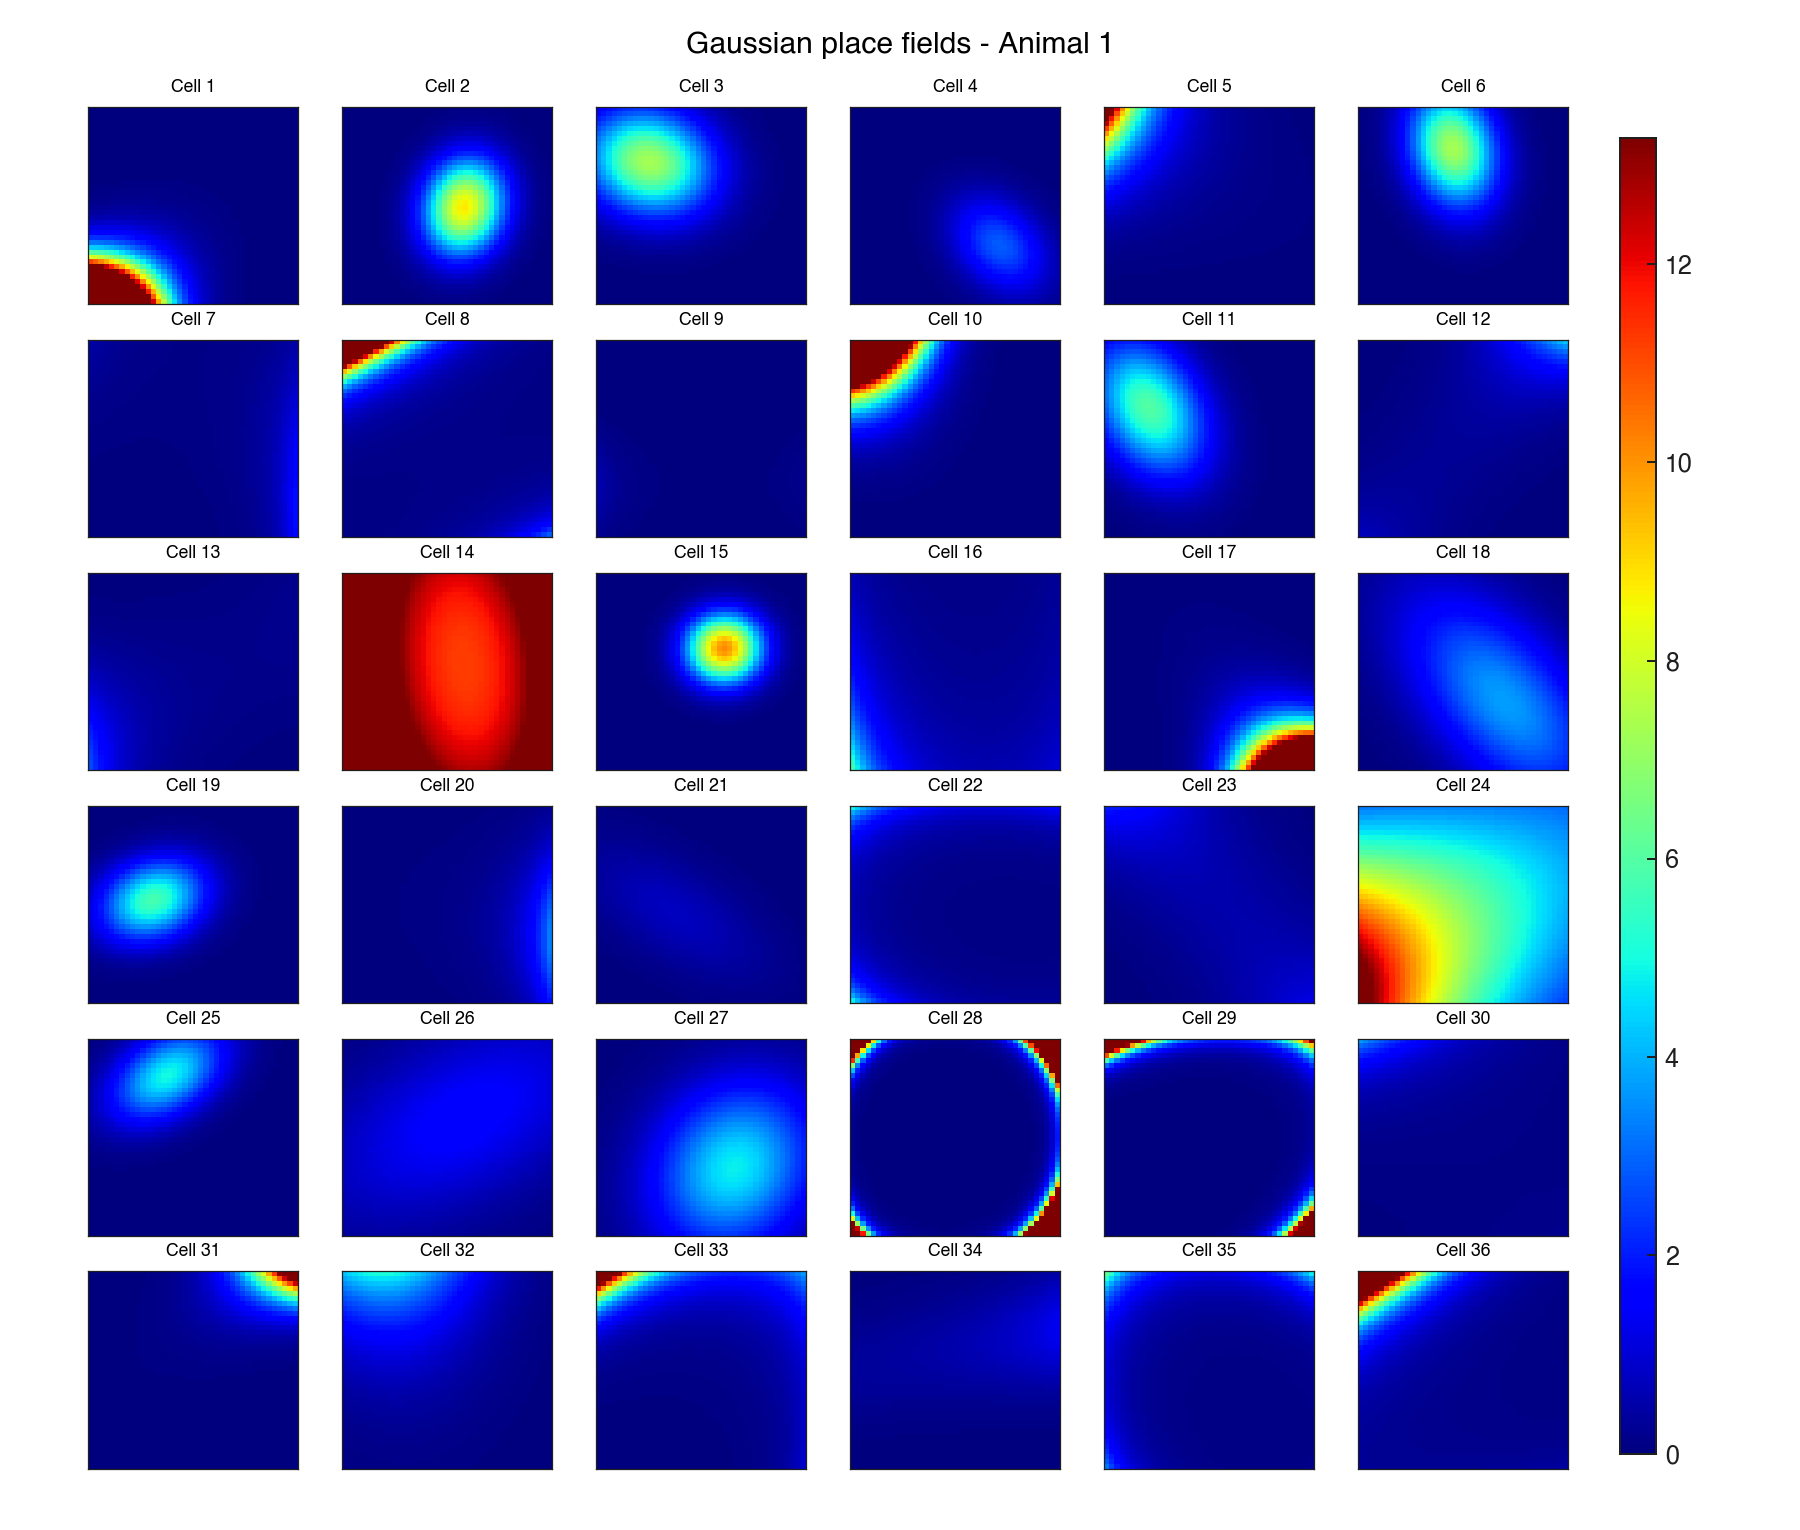

In [ ]:
# SECTION 3: View Summary Statistics
# Same collapse as cell 4: MATLAB emits a single Summary.plotSummary figure with
# AIC/BIC subplots; mirror that so the figure ordering matches MATLAB downstream.
fig = _prepare_figure("Summary.plotSummary", figsize=(7.5, 7.0))
animal2 = payload["animal2"]
labels = [f"Cell {int(idx) + 1}" for idx in np.asarray(animal2["selected_indices"], dtype=int)]
ax_a, ax_b = fig.subplots(2, 1, sharex=True)
ax_a.bar(np.arange(len(labels)), animal2["delta_aic"], color="#0072BD", edgecolor="k", linewidth=0.5)
ax_a.axhline(0.0, color="0.2", linewidth=1.0)
ax_a.set_ylabel("Gaussian - Zernike AIC")
ax_a.set_title("Animal 2 model comparison")
ax_b.bar(np.arange(len(labels)), animal2["delta_bic"], color="#0072BD", edgecolor="k", linewidth=0.5)
ax_b.axhline(0.0, color="0.2", linewidth=1.0)
ax_b.set_xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
ax_b.set_ylabel("Gaussian - Zernike BIC")


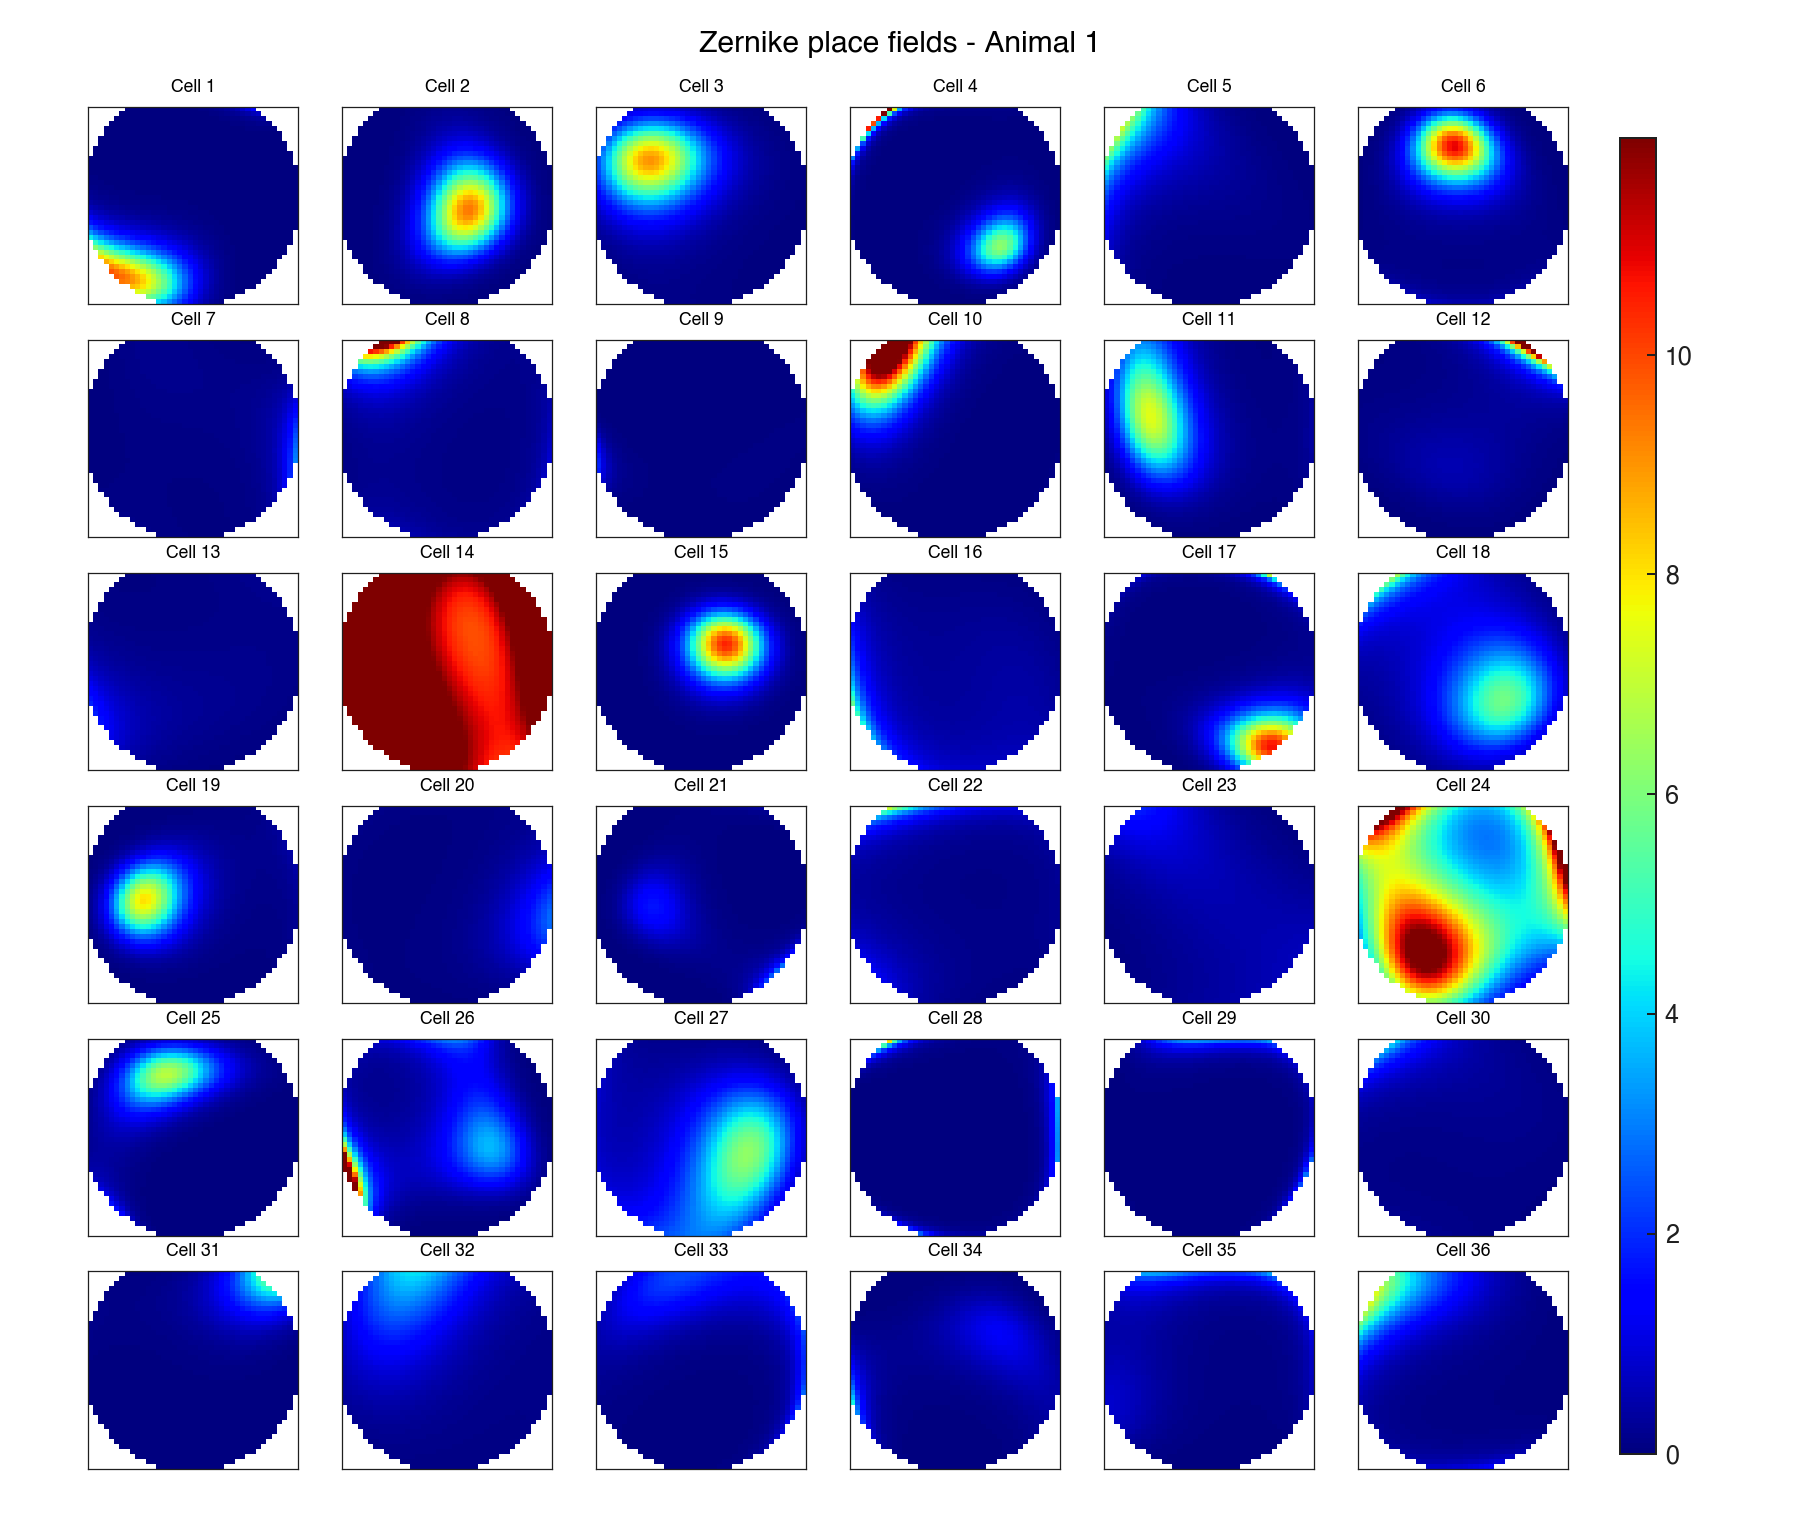

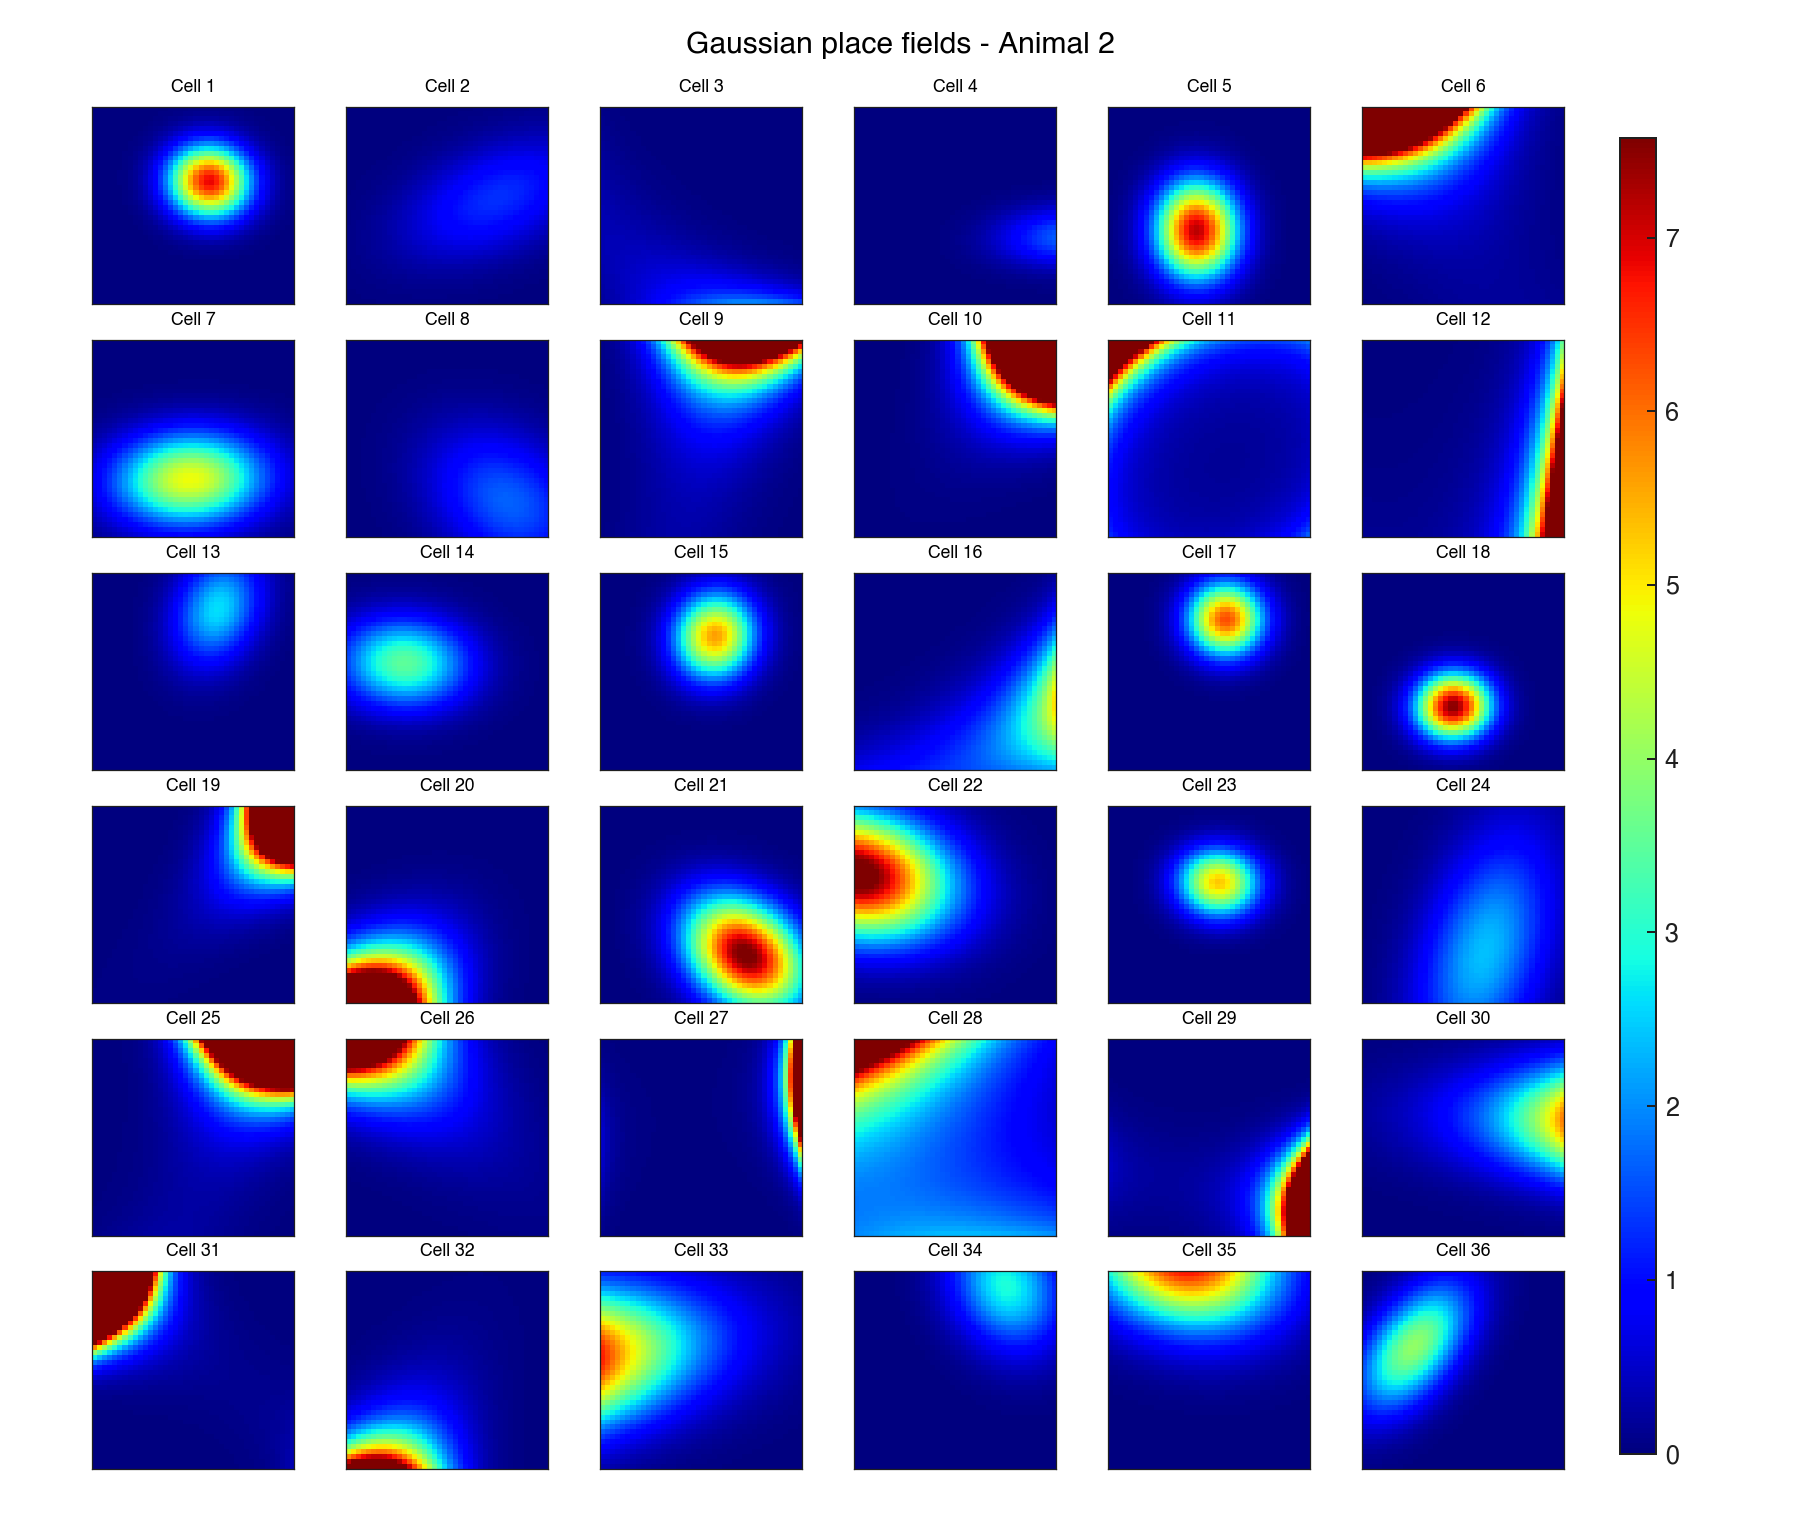

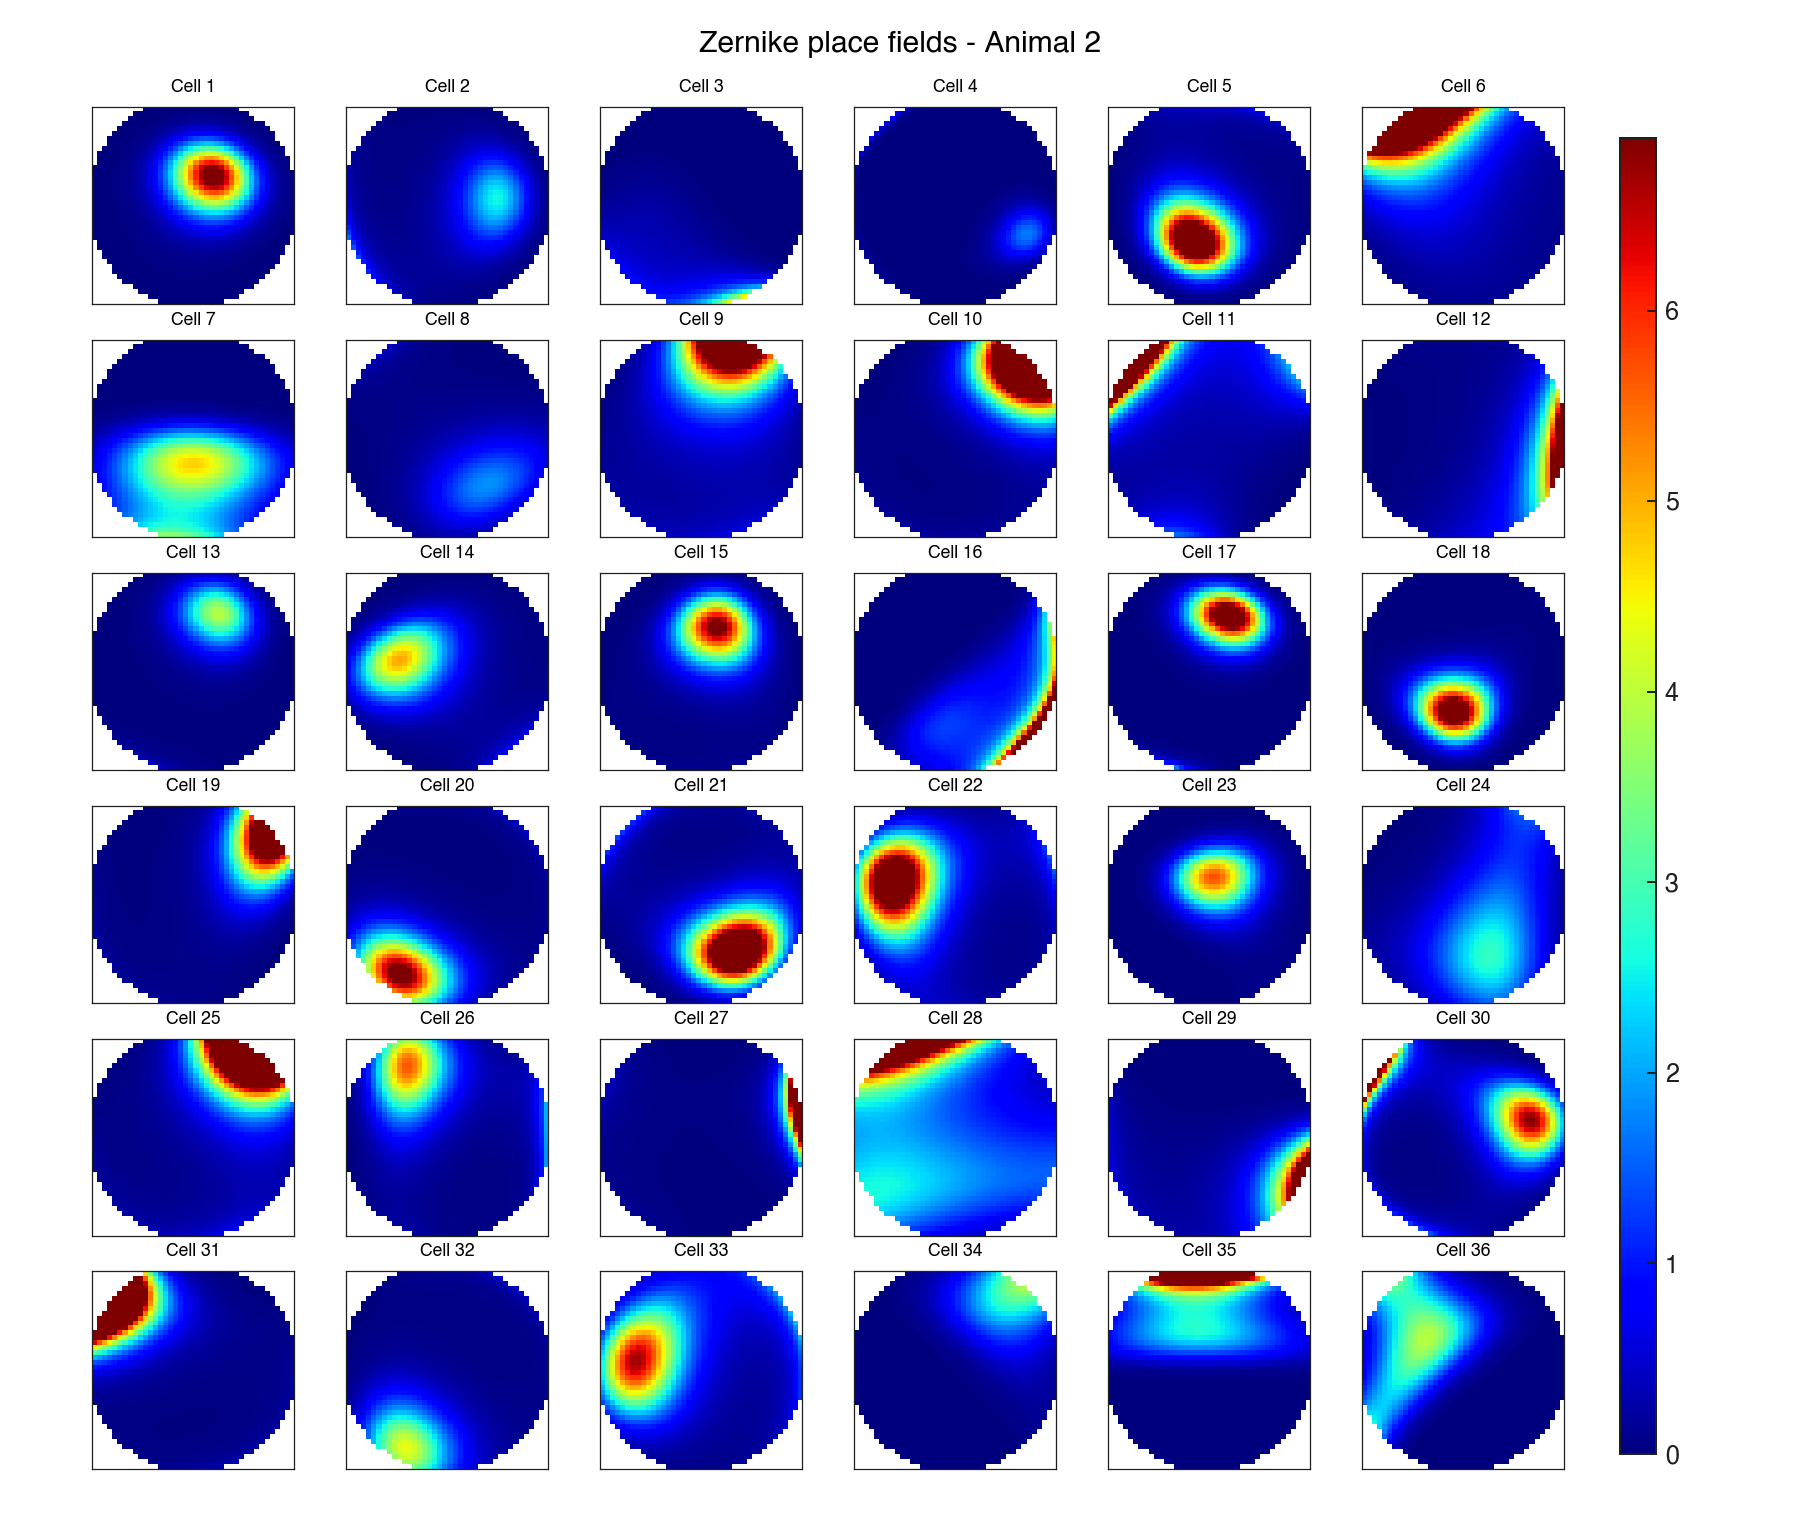

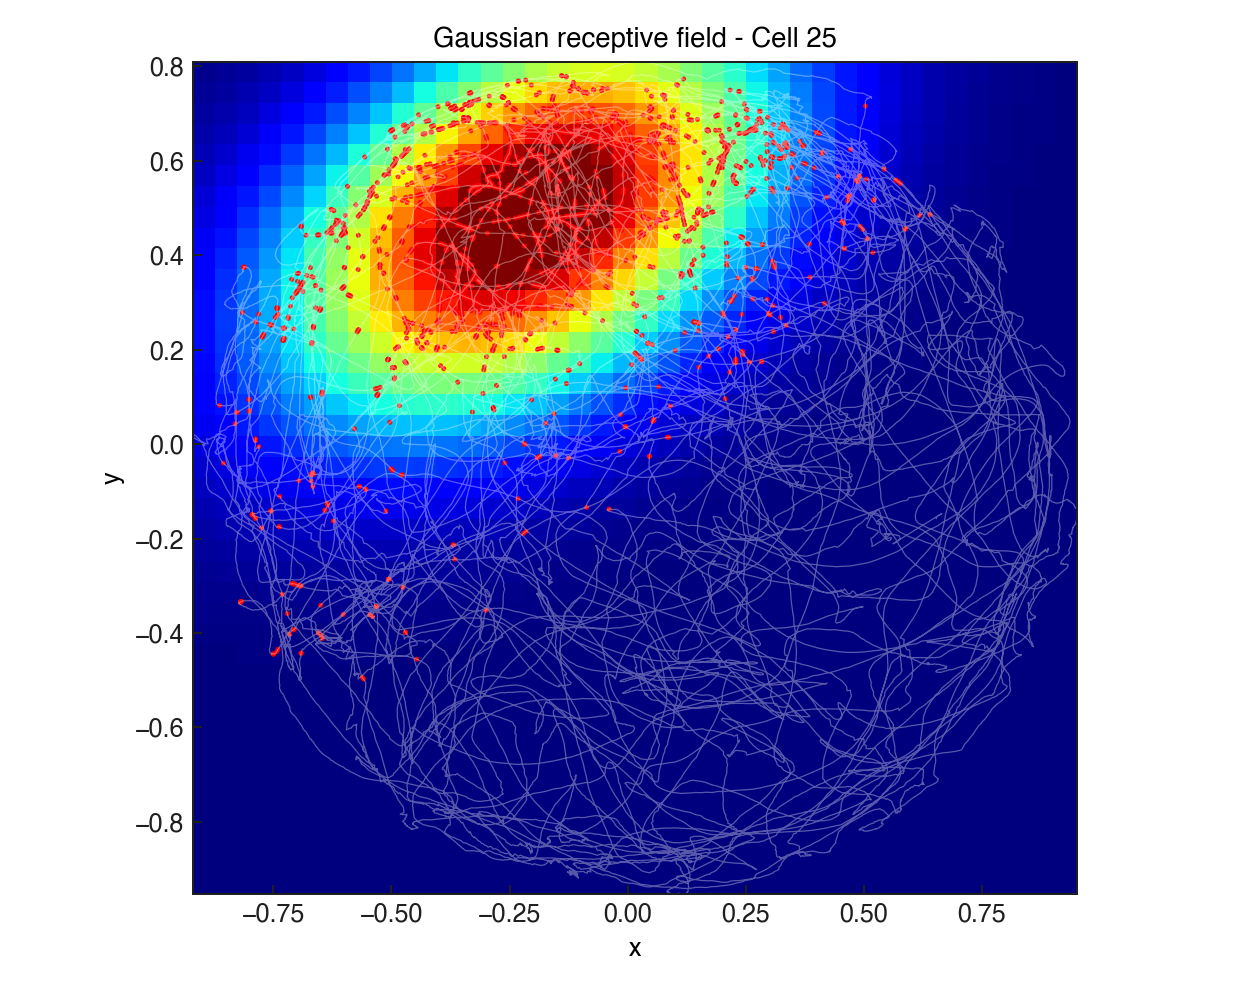

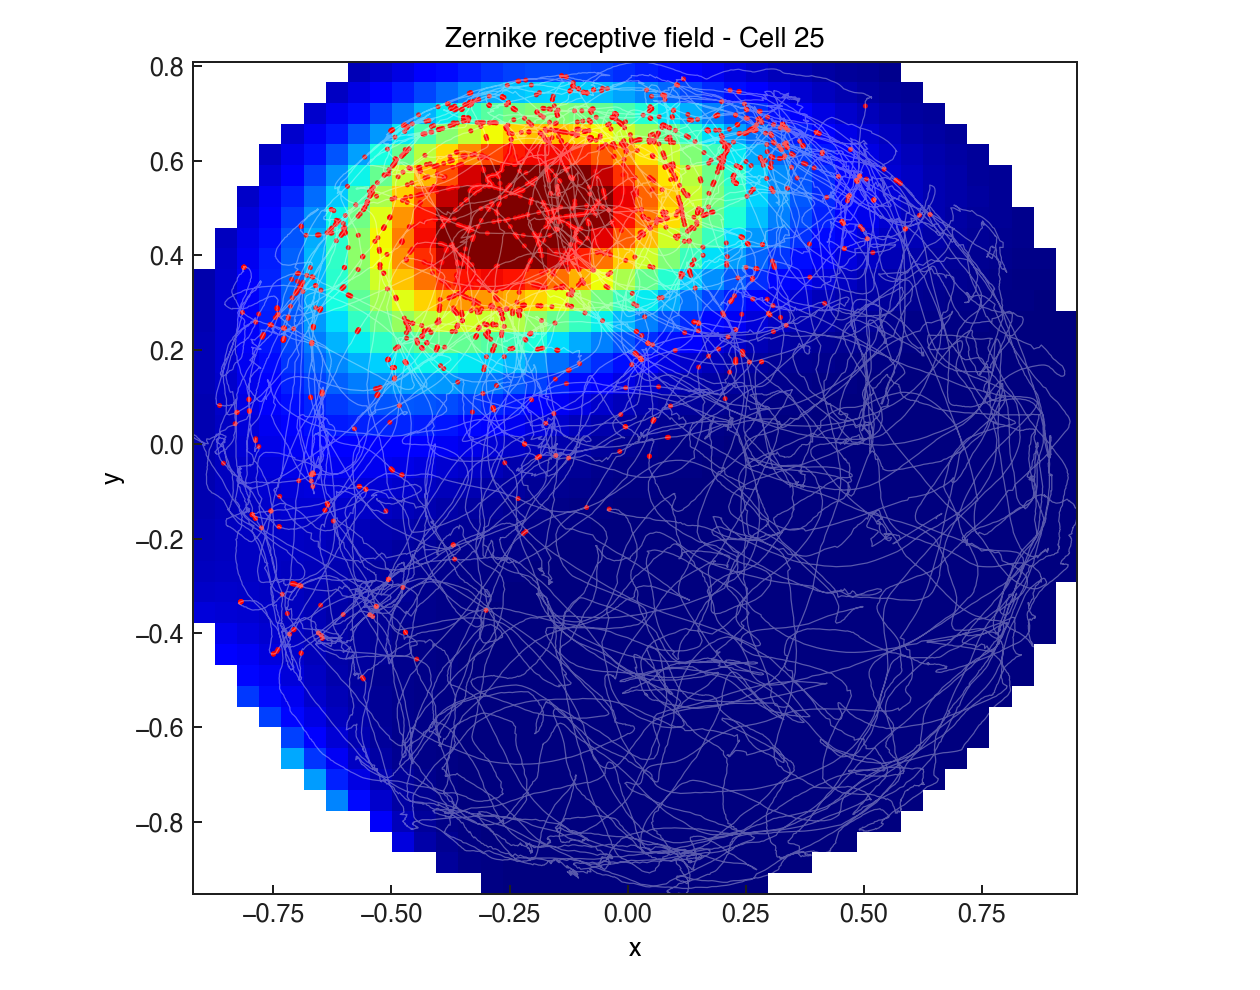

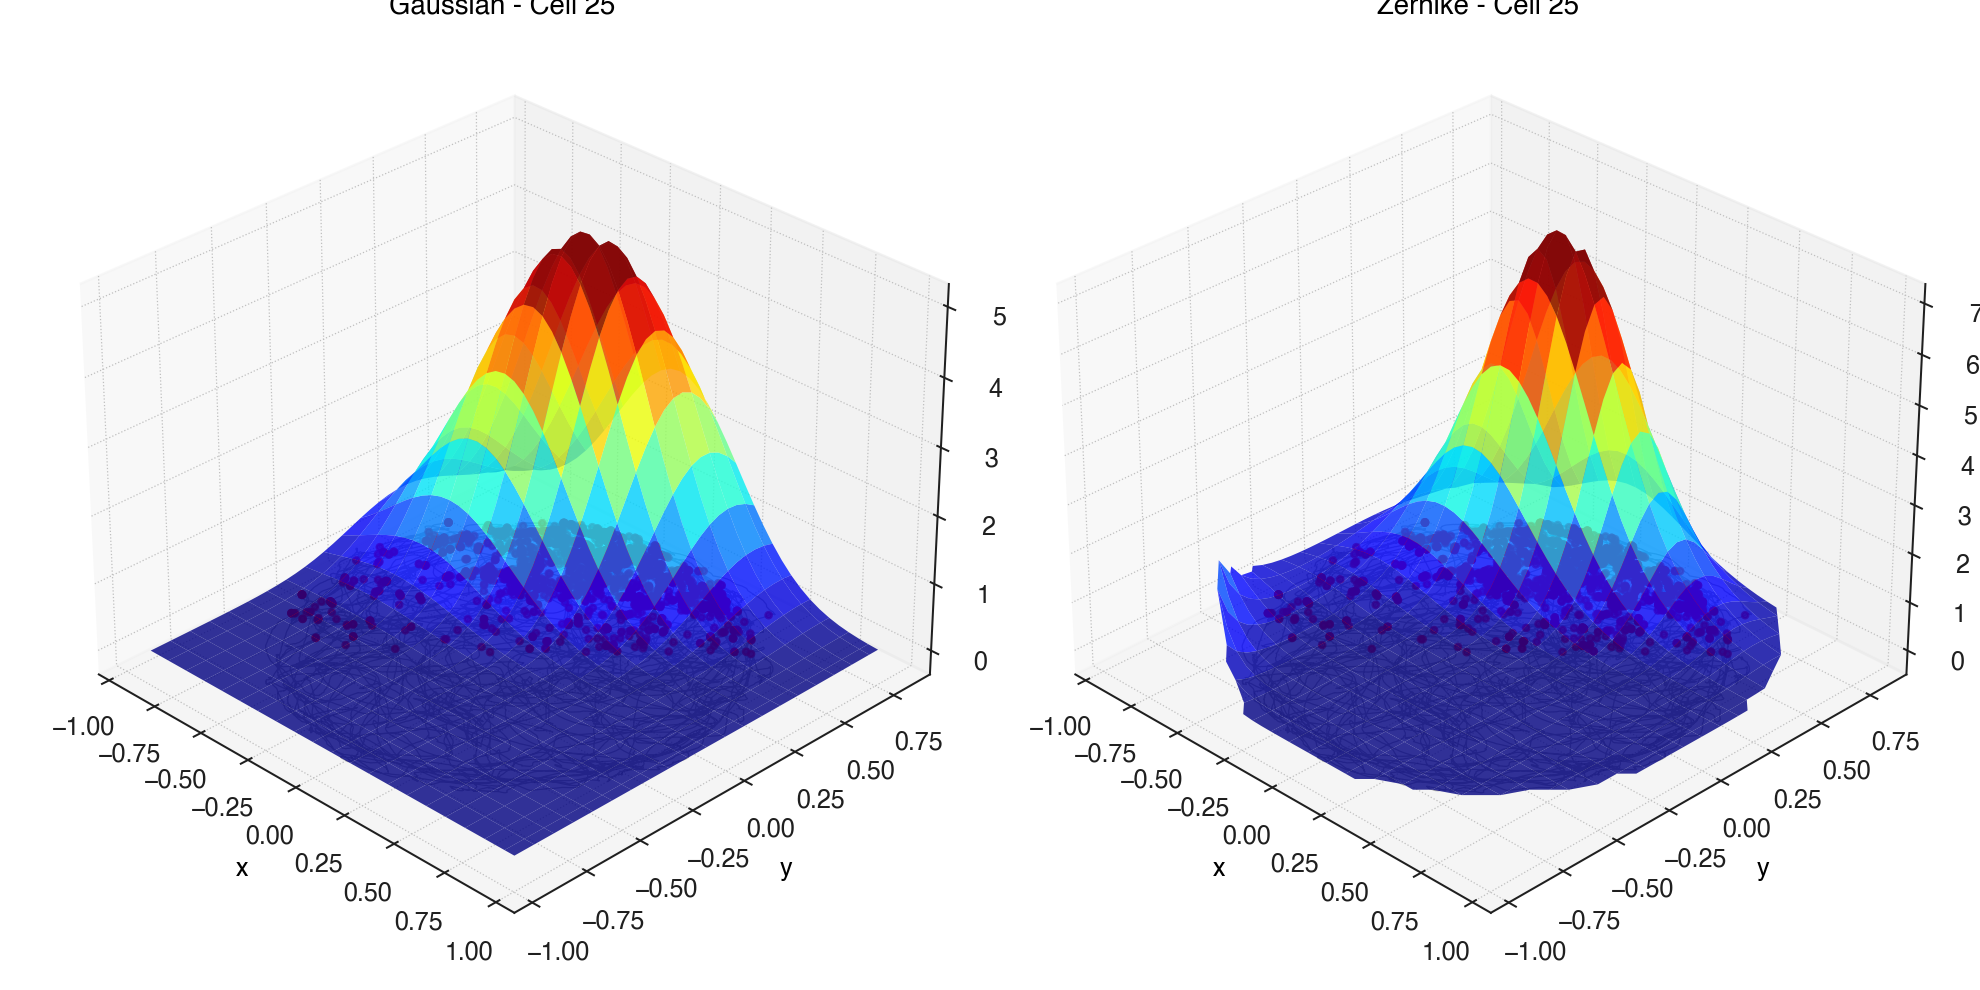

In [ ]:
# SECTION 4: Visualize the results
fig = _prepare_figure("h4=figure(4)", figsize=(10.0, 8.5))
_plot_field_grid(fig, "animal1", "gaussian_fields", "Gaussian place fields - Animal 1")

fig = _prepare_figure("h5=figure(5)", figsize=(10.0, 8.5))
_plot_field_grid(fig, "animal1", "zernike_fields", "Zernike place fields - Animal 1")

fig = _prepare_figure("h6=figure(6)", figsize=(10.0, 8.5))
_plot_field_grid(fig, "animal2", "gaussian_fields", "Gaussian place fields - Animal 2")

fig = _prepare_figure("h7=figure(7)", figsize=(10.0, 8.5))
_plot_field_grid(fig, "animal2", "zernike_fields", "Zernike place fields - Animal 2")

fig = _prepare_figure("figure(8)", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
_g_vmax = float(np.nanpercentile(np.asarray(mesh["gaussian_field"], dtype=float), 98))
ax.imshow(
    mesh["gaussian_field"],
    origin="lower",
    extent=[float(np.min(mesh["grid_x"])), float(np.max(mesh["grid_x"])), float(np.min(mesh["grid_y"])), float(np.max(mesh["grid_y"]))],
    aspect="equal",
    cmap="jet",
    vmin=0.0,
    vmax=_g_vmax,
)
ax.plot(mesh["x_pos"], mesh["y_pos"], color="white", linewidth=0.5, alpha=0.35)
ax.scatter(spike_x, spike_y, s=4, color="r", edgecolors="none", alpha=0.85)
ax.set_title(f"Gaussian receptive field - Cell {int(mesh['cell_index']) + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")

fig = _prepare_figure("figure(9)", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
_z_vmax = float(np.nanpercentile(np.asarray(mesh["zernike_field"], dtype=float), 98))
ax.imshow(
    mesh["zernike_field"],
    origin="lower",
    extent=[float(np.min(mesh["grid_x"])), float(np.max(mesh["grid_x"])), float(np.min(mesh["grid_y"])), float(np.max(mesh["grid_y"]))],
    aspect="equal",
    cmap="jet",
    vmin=0.0,
    vmax=_z_vmax,
)
ax.plot(mesh["x_pos"], mesh["y_pos"], color="white", linewidth=0.5, alpha=0.35)
ax.scatter(spike_x, spike_y, s=4, color="r", edgecolors="none", alpha=0.85)
ax.set_title(f"Zernike receptive field - Cell {int(mesh['cell_index']) + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")

# figure(9) overlay — matches MATLAB hold-on composite (published as _10.png).
# Reviewer asked for equal-aspect side-by-side panels with identical xlim/ylim
# so the two heatmaps line up tile-for-tile.
fig = _prepare_figure("figure(9) overlay", figsize=(10.0, 5.0))
axs = fig.subplots(1, 2)
ext = [float(np.min(mesh["grid_x"])), float(np.max(mesh["grid_x"])), float(np.min(mesh["grid_y"])), float(np.max(mesh["grid_y"]))]
for ax, field, label in zip(axs, [mesh["gaussian_field"], mesh["zernike_field"]], ["Gaussian", "Zernike"]):
    _vmax = float(np.nanpercentile(np.asarray(field, dtype=float), 98))
    ax.imshow(field, origin="lower", extent=ext, aspect="equal", cmap="jet", vmin=0.0, vmax=_vmax)
    ax.plot(mesh["x_pos"], mesh["y_pos"], color="white", linewidth=0.5, alpha=0.35)
    ax.scatter(spike_x, spike_y, s=4, color="r", edgecolors="none", alpha=0.85)
    ax.set_title(f"{label} - Cell {int(mesh['cell_index']) + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_aspect("equal", adjustable="box")

# 3D mesh overlay — MATLAB renders Gaussian vs Zernike tuning surfaces side-by-side
# with a jet colormap and a fixed camera angle.  Render the two surfaces in a
# (1, 2) 3D subplot grid using `plot_surface` with cmap='jet' so the colors
# encode firing rate (reviewer-requested).  Trajectory + spikes are dropped onto
# the bottom z-plane for context.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3d projection
fig = _prepare_figure("figure(9) 3D mesh overlay", figsize=(11.0, 5.5))
fig.clear()
X = np.asarray(mesh["grid_x"], dtype=float)
Y = np.asarray(mesh["grid_y"], dtype=float)
gauss = np.asarray(mesh["gaussian_field"], dtype=float)
zern = np.asarray(mesh["zernike_field"], dtype=float)
z_floor = float(np.nanmin([np.nanmin(gauss), np.nanmin(zern), 0.0]))
for i, (Z, label) in enumerate([(gauss, "Gaussian"), (zern, "Zernike")], start=1):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    _vmax = float(np.nanpercentile(Z, 98)) or 1.0
    ax.plot_surface(X, Y, Z, rstride=2, cstride=2, cmap="jet", vmin=0.0, vmax=_vmax,
                    alpha=0.8, linewidth=0.0, antialiased=True)
    ax.plot(np.asarray(mesh["x_pos"], dtype=float), np.asarray(mesh["y_pos"], dtype=float),
            zs=z_floor, zdir="z", color="0.4", linewidth=0.5, alpha=0.5)
    ax.scatter(spike_x, spike_y, zs=z_floor, zdir="z", s=6, color="r", alpha=0.7)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("Hz")
    ax.set_title(f"{label} - Cell {int(mesh['cell_index']) + 1}")
    ax.view_init(elev=30, azim=-45)

__tracker.finalize()
